# Построение регрессии для log1p(SI)

In [1]:
# Python 3.14.3

import pandas as pd
import numpy as np

## Настройка

In [2]:
from pathlib import Path


RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

ALL_TARGET_COLS = [
    "pIC50",
    "pCC50",
    "log1p_SI",
    "IC50, mM", 
    "CC50, mM", 
    "SI"
]

DATA_FOR_MODEL_PATH = Path('./output/indata_processed.csv')

## Загрузка данных

In [3]:
from dataclasses import dataclass, field
from sklearn.model_selection import train_test_split


@dataclass
class Dataset:
    X_train: pd.DataFrame
    X_test: pd.DataFrame
    y_train: pd.Series
    y_test: pd.Series
    feature_names: list[str]
    y_column: str


# загрузка датасета
def load_data():
    if not DATA_FOR_MODEL_PATH.exists():
        raise FileNotFoundError("Не найден файл подготовленных данных")
    return pd.read_csv(DATA_FOR_MODEL_PATH)


# проврека целевая или нет
def is_target_col(name: str):
    if name in ALL_TARGET_COLS:
        return True
    else:
        return False
    

# список признаков
def get_feature_cols(df: pd.DataFrame):
    return [c for c in df.columns if not is_target_col(c)]


# подготовка данных для обучения
def prepare_dataset(df: pd.DataFrame, y_col: str):
    if y_col not in df.columns:
        raise ValueError(f"Столбец {y_col} отсутствует в данных")
    
    feat = get_feature_cols(df)
    X = df[feat].astype(float)
    y = df[y_col].astype(float)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    return Dataset(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        feature_names=feat,
        y_column=y_col
    )

## Обучение
### Создаю единую спецификацию моделей

In [4]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# спецификации
model_specs = {
    "linear": {
        "name": "Linear",
        "pipeline": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LinearRegression())
        ]),
        "param_grid": {
            "model__fit_intercept": [True, False]
        }
    },
    "ridge": {
        "name": "Ridge",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__alpha": np.linspace(-3, 3, 6),
            "model__solver": ['auto', 'svd', 'lsqr', 'sag', 'lbfgs']
        }
    },
    "decision_tree": {
        "name": "Decision Tree",
        "pipeline": Pipeline([
            ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__criterion": ['squared_error', 'absolute_error', 'poisson'],
            "model__max_depth": [None, 3, 5, 10],
            "model__min_samples_split": [1, 3, 9],
            "model__min_samples_leaf": [1, 3]
        }
    },
    "random_forest": {
        "name": "Random Forest",
        "pipeline": Pipeline([
            ("model", RandomForestRegressor(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__max_depth": [None, 15],
            "model__min_samples_split": [2, 6],
            "model__min_samples_leaf": [1, 3],
            "model__n_estimators": [50, 100, 200],
            "model__max_features": ["sqrt", "log2"]
        }
    },
    "svr": {
        "name": "SVR",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR())
        ]),
        "param_grid": {
            "model__kernel": ["rbf", "linear", "sigmoid"],
            "model__C": [0.1, 1, 10],
            "model__epsilon": [0.01, 0.1, 1],
            "model__gamma": ["scale", "auto"]
        }
    },
    "knn": {
        "name": "KNeighbors",
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor(n_jobs=-1))
        ]),
        "param_grid": {
            "model__n_neighbors": [3, 5, 7, 11],
            "model__weights": ['uniform', 'distance'],
            "model__algorithm": ["ball_tree", "kd_tree", "brute"],
            "model__leaf_size": [3, 30, 300]
        }
    },
    "gradient_boosting": {
        "name": "Hist Gradient Boosting",
        "pipeline": Pipeline([
            ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__loss": ["squared_error", "absolute_error", "poisson", "quantile"],
            "model__learning_rate": [0.05, 0.1, 1],
            "model__max_depth": [3, 5, 8],
            "model__max_iter": [100, 200],
        }
    },
    "extra_trees": {
        "name": "Extra Trees",
        "pipeline": Pipeline([
            ("model", ExtraTreesRegressor(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__n_estimators": [50, 100, 250],
            "model__criterion": ["squared_error", "absolute_error", "friedman_mse", "poisson"],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 10]
        }
    }
}


# единая функция создания + GridSearchCV
def create_estimator(name: str, cv: int):
    if name not in model_specs.keys():
        raise KeyError(f"Неизвестная модель {name}")
    
    spec = model_specs[name]
    search = GridSearchCV(
        spec["pipeline"],
        spec["param_grid"],
        cv=cv,
        scoring = "neg_root_mean_squared_error",
        n_jobs=-1,
        refit=True
    )
    return search, spec

### Обучение

In [5]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


@dataclass
class ModelResult:
    spec_name: str
    best_params: dict
    cv_metrics: dict[str, float]
    test_metrics: dict[str, float]
    y_pred_test: np.ndarray = field(repr=False)


def regression_metrics(y_true, y_pred):
    y_true = np.asanyarray(y_true)
    y_pred = np.asanyarray(y_pred)
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred)
    }


# среднее и std по fold
def cv_aggregate(scores: dict):
    res = {}
    for name, values in scores.items():
        clean = name.replace("test_", "")
        arr = np.array(values, dtype=float)
        if "neg_" in name or clean in ("rmse", "mae", "neg_root_mean_squared_error"):
            arr = -arr
            clean = clean.replace("neg_", "").replace("neg_root_mean_squared_error", "rmse")
        res[f"cv_{clean}_mean"] = float(np.mean(arr))
        res[f"cv_{clean}_std"] = float(np.std(arr))
    return res


# обучение модели
def train_model(dataset: Dataset, model_name: str):
    search, spec = create_estimator(model_name, CV_FOLDS)
    
    X_train = dataset.X_train
    y_train = dataset.y_train

    print(f"Обучается модель: {spec["name"]}")
    search.fit(X_train, y_train)

    cv_raw = cross_validate(
        search.best_estimator_,
        X_train, y_train,
        cv=CV_FOLDS,
        scoring={
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2"
        },
        n_jobs=-1
    )

    cv_metrics = cv_aggregate(cv_raw)

    y_pred = search.predict(dataset.X_test.values)
    test_metrics = regression_metrics(dataset.y_test, y_pred)

    return ModelResult(
        spec_name=model_name,
        best_params=search.best_params_,
        cv_metrics=cv_metrics,
        test_metrics=test_metrics,
        y_pred_test=y_pred
    )


# обучаем все модели из спецификации
def train_all_models(dataset: Dataset):
    models = []

    for model_name in model_specs:
        models.append(train_model(dataset, model_name))
    return models

In [6]:
import warnings
warnings.filterwarnings('ignore')


df = load_data()
dataset = prepare_dataset(df, "log1p_SI")
models = train_all_models(dataset)

Обучается модель: Linear
Обучается модель: Ridge
Обучается модель: Decision Tree
Обучается модель: Random Forest
Обучается модель: SVR
Обучается модель: KNeighbors
Обучается модель: Hist Gradient Boosting
Обучается модель: Extra Trees


## Выводим результаты обучения моделей

In [7]:
# выводим результаты
for m in models:
    print(f"\nmodel: {model_specs[m.spec_name]["name"]}")
    print("Test metrics:")
    for k, v in m.test_metrics.items():
        print(f"\t{k}: {v:.3f}")
    print(f"CV metrics:")
    for k, v in m.cv_metrics.items():
        print(f"\t{k}: {v:.3f}")
    print(f"best params:")
    for k, v in m.best_params.items():
        print(f"\t{k}: {v}")


model: Linear
Test metrics:
	rmse: 1.498
	mae: 1.115
	r2: 0.152
CV metrics:
	cv_fit_time_mean: 0.012
	cv_fit_time_std: 0.002
	cv_score_time_mean: 0.006
	cv_score_time_std: 0.001
	cv_rmse_mean: 1.286
	cv_rmse_std: 0.066
	cv_mae_mean: 0.993
	cv_mae_std: 0.061
	cv_r2_mean: 0.162
	cv_r2_std: 0.060
best params:
	model__fit_intercept: True

model: Ridge
Test metrics:
	rmse: 1.500
	mae: 1.119
	r2: 0.150
CV metrics:
	cv_fit_time_mean: 0.006
	cv_fit_time_std: 0.001
	cv_score_time_mean: 0.004
	cv_score_time_std: 0.000
	cv_rmse_mean: 1.281
	cv_rmse_std: 0.061
	cv_mae_mean: 0.990
	cv_mae_std: 0.057
	cv_r2_mean: 0.169
	cv_r2_std: 0.053
best params:
	model__alpha: 3.0
	model__solver: auto

model: Decision Tree
Test metrics:
	rmse: 1.526
	mae: 1.014
	r2: 0.121
CV metrics:
	cv_fit_time_mean: 0.044
	cv_fit_time_std: 0.003
	cv_score_time_mean: 0.004
	cv_score_time_std: 0.001
	cv_rmse_mean: 1.263
	cv_rmse_std: 0.035
	cv_mae_mean: 0.907
	cv_mae_std: 0.048
	cv_r2_mean: 0.189
	cv_r2_std: 0.072
best params:

## Сравниваем на графиках

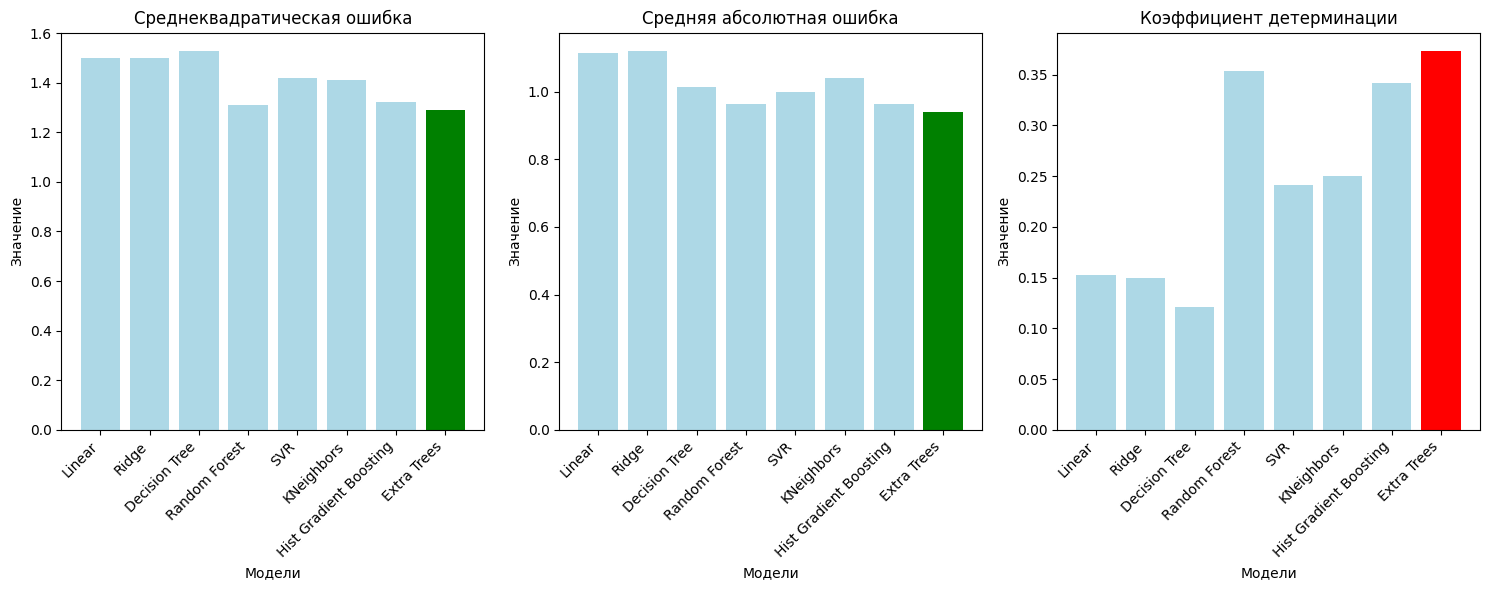

In [8]:
import matplotlib.pyplot as plt

model_names = [model_specs[m.spec_name]["name"] for m in models]
rmse_values = [m.test_metrics["rmse"] for m in models]
mae_values = [m.test_metrics["mae"] for m in models]
r2_values = [m.test_metrics["r2"] for m in models]
values = [rmse_values, mae_values, r2_values]
titles = [
    "Среднеквадратическая ошибка", 
    "Средняя абсолютная ошибка",
    "Коэффициент детерминации"
]

x = np.arange(len(model_names))
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, (label, vals) in enumerate(zip(titles, values)):
    if i == 2:
        best_m = max(vals)
        best_i = vals.index(best_m)
        col = "red"
    else:
        best_m = min(vals)
        best_i = vals.index(best_m)
        col = "green"

    colors = ["lightblue"] * len(model_names)
    colors[best_i] = col

    axes[i].bar(x, vals, color=colors)
    axes[i].set_xlabel("Модели")
    axes[i].set_ylabel("Значение")
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(model_names, rotation=45, ha="right")
    axes[i].set_title(label)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Определяем лучшую модель по $R^2$

In [ ]:
from scipy.stats import spearmanr


best_model_spec_name = ""
best_r2 = 0
best_model_idx = 0

for i, m in enumerate(models):
    if m.test_metrics["r2"] > best_r2:
        best_r2 = m.test_metrics["r2"]
        best_model_spec_name = m.spec_name
        best_model_idx = i

best_model = model_specs[best_model_spec_name]["name"]
print(f"Лучшая модель: {best_model}")
pipe = model_specs[best_model_spec_name]["pipeline"]
pipe.set_params(**models[best_model_idx].best_params)

dataset = prepare_dataset(load_data(), 'log1p_SI')
pipe.fit(dataset.X_train, dataset.y_train)
y_true = prepare_dataset(load_data(), 'SI').y_test
y_pred = pipe.predict(dataset.X_test)
y_pred_real = list(map(lambda x: np.expm1(x), y_pred))


spr = spearmanr(y_true, y_pred_real)
ape = np.abs(y_true - np.expm1(y_pred)) / (y_true + 1e-6) 

print("Финальные метрики на целевых данных (test):")
print(f"Корреляция Спирмена\n\tstatistic: {spr.statistic:.3f}\n\tp-value: {spr.pvalue:.4f}")
print(f"Среднее модуля относительной ошибки: {np.median(ape):.3f}")

Лучшая модель: Extra Trees
Финальные метрики на целевых данных (test):
Корреляция Спирмена
	statistic: 0.461
	p-value: 0.0000
Среднее модуля относительной ошибки: 0.828


## Важность признаков: топ-3 модели

- по результатам сравнения на test выбираем 3 лучшие модели по $R^2$
- переобучаем пайплайны с уже найденными гиперпараметрами
- строим один совмещённый график сравнение важности признаков

Топ-3 по r2 (test):
  - Extra Trees: 0.373
  - Random Forest: 0.353
  - Hist Gradient Boosting: 0.342


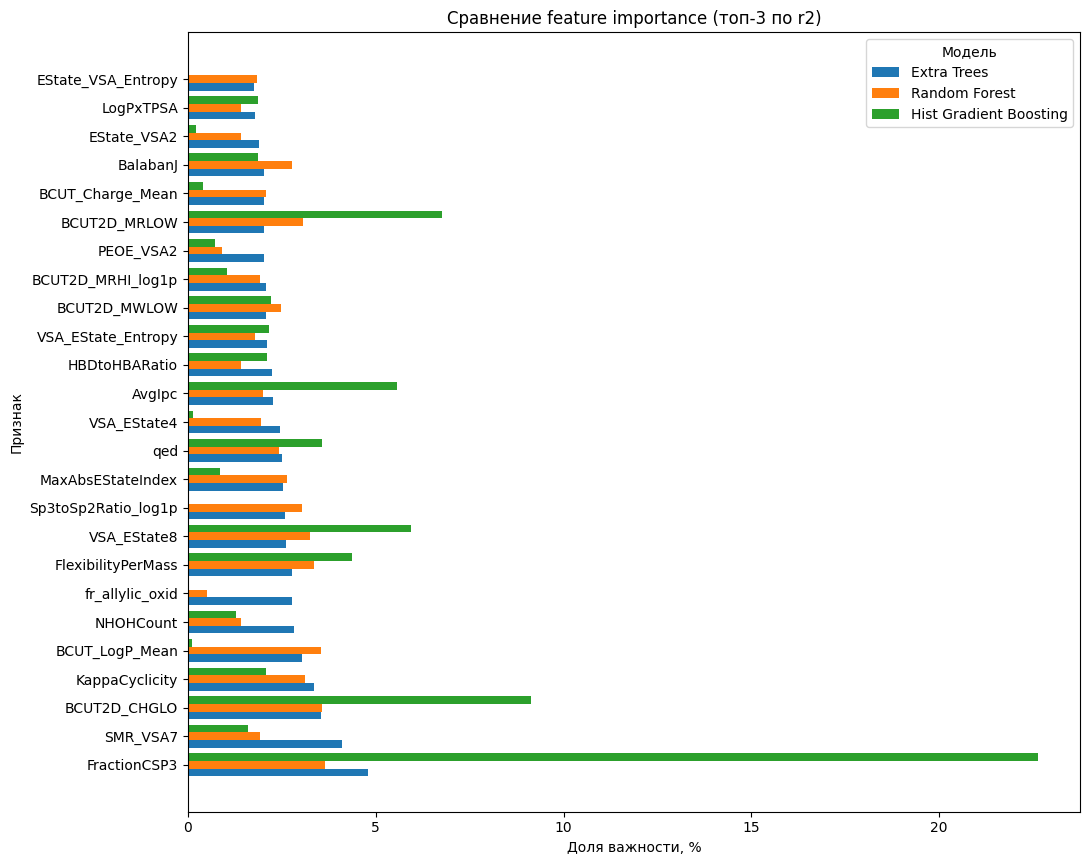

In [10]:
from sklearn.inspection import permutation_importance
from sklearn.base import clone


METRIC = "r2"


# считаем важность признаков
def feature_importance(fitted_pipe, X_ref, y_ref, feature_names):
    est = fitted_pipe.named_steps["model"]
    if hasattr(est, "feature_importances_"):
        vals = est.feature_importances_
    elif hasattr(est, "coef_"):
        coef = np.asarray(est.coef_)
        vals = np.abs(coef.ravel()) if coef.ndim == 1 else np.mean(np.abs(coef), axis=0)
    else:
        perm = permutation_importance(
            fitted_pipe,
            X_ref,
            y_ref,
            n_repeats=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            scoring="neg_root_mean_squared_error",
        )
        vals = perm.importances_mean
    return pd.Series(vals, index=feature_names)


# обучаем модель
def fit_with_params(spec_name, params):
    pipe = clone(model_specs[spec_name]["pipeline"])
    pipe.set_params(**params)
    pipe.fit(dataset.X_train, dataset.y_train)
    return pipe


feature_names = list(dataset.X_train.columns)
top_models = sorted(models, key=lambda m: m.test_metrics[METRIC], reverse=True)[:3]

importance_df = pd.DataFrame(index=feature_names)

# находим 3 лучшие модели
print(f"Топ-3 по {METRIC} (test):")
for m in top_models:
    name = model_specs[m.spec_name]["name"]
    print(f"  - {name}: {m.test_metrics[METRIC]:.3f}")
    fitted = fit_with_params(m.spec_name, m.best_params)
    importance_df[name] = feature_importance(
        fitted, dataset.X_test, dataset.y_test, feature_names
    )

# доля важности в % по каждой модели
importance_notneg = importance_df.clip(lower=0)
importance_pct = importance_notneg.div(importance_notneg.sum(axis=0), axis=1) * 100

# топ-25 признаков по лучшей модели
best_model_name = model_specs[top_models[0].spec_name]["name"]
plot_feats = importance_pct[best_model_name].sort_values(ascending=False).head(25).index
plot_df = importance_pct.loc[plot_feats]

# строим график
fig, ax = plt.subplots(figsize=(11, max(6, 0.35 * len(plot_df))))
y = np.arange(len(plot_df))
bar_h = 0.8 / plot_df.shape[1]

for i, col in enumerate(plot_df.columns):
    offset = (i - (plot_df.shape[1] - 1) / 2) * bar_h
    ax.barh(y + offset, plot_df[col].values, height=bar_h, label=col)

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Доля важности, %")
ax.set_ylabel("Признак")
ax.set_title(f"Сравнение feature importance (топ-3 по {METRIC})")
ax.legend(title="Модель", loc="upper right")
plt.tight_layout()
plt.show()